In [28]:
# entropy ->  -p(+)logp(+) - p(-)logp(-)
# gini -> 1 - p(+)^2 - p(-)^2
# use gini for continuous and large  data and entropy for categorical and small data
#information gain -> H(s) - sum (|s_v|/|s| * H(s_v)) where s_v is the subset of s for which attribute A has value v



##### Post Pruning

we take small data set , it creates small decision tree and then we can prune it to avoid overfitting.we can also prune the tree after it has been built. This is called post-pruning. In this method, we first build a full tree and then remove nodes that do not provide significant power in predicting the target variable. This helps in reducing the complexity of the model and prevents overfitting.

In [29]:
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import load_iris



In [30]:
iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [31]:
iris_data = pd.DataFrame(iris.data, columns=iris.feature_names)

iris_data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [32]:
df = sns.load_dataset("iris")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [33]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)


DecisionTreeClassifier()

[Text(257.53846153846155, 504.7714285714286, 'X[3] <= 0.8\ngini = 0.666\nsamples = 112\nvalue = [35, 39, 38]'),
 Text(193.15384615384616, 427.11428571428576, 'gini = 0.0\nsamples = 35\nvalue = [35, 0, 0]'),
 Text(321.9230769230769, 427.11428571428576, 'X[2] <= 4.75\ngini = 0.5\nsamples = 77\nvalue = [0, 39, 38]'),
 Text(128.76923076923077, 349.4571428571429, 'X[3] <= 1.65\ngini = 0.056\nsamples = 35\nvalue = [0, 34, 1]'),
 Text(64.38461538461539, 271.8, 'gini = 0.0\nsamples = 34\nvalue = [0, 34, 0]'),
 Text(193.15384615384616, 271.8, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(515.0769230769231, 349.4571428571429, 'X[3] <= 1.75\ngini = 0.21\nsamples = 42\nvalue = [0, 5, 37]'),
 Text(321.9230769230769, 271.8, 'X[2] <= 4.95\ngini = 0.5\nsamples = 8\nvalue = [0, 4, 4]'),
 Text(257.53846153846155, 194.14285714285717, 'gini = 0.0\nsamples = 2\nvalue = [0, 2, 0]'),
 Text(386.3076923076923, 194.14285714285717, 'X[3] <= 1.55\ngini = 0.444\nsamples = 6\nvalue = [0, 2, 4]'),
 Text(321.9

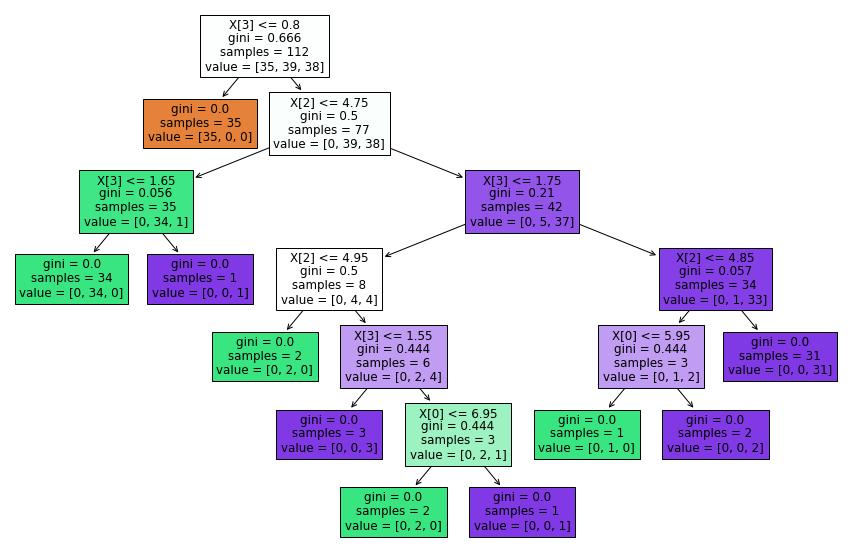

In [34]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(model, filled=True)

In [35]:
# above we see that the tree is overfitting the data as it is very complex and has many nodes. To avoid this we can prune the tree by setting the max_depth parameter in DecisionTreeClassifier. This will limit the depth of the tree and prevent it from overfitting. 

model_pruned = DecisionTreeClassifier(max_depth=3)
model_pruned.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [39]:
model_pruned.predict(X_test)
model_pruned.score(X_test, y_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, model_pruned.predict(X_test))
print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(classification_report(y_test, model_pruned.predict(X_test)))
print("Confusion Matrix:")
print(confusion_matrix(y_test, model_pruned.predict(X_test)))

Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        11
   virginica       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

Confusion Matrix:
[[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]


##### Pre Pruning

we prune the tree before it has been built. This is called pre-pruning. In this method, we set a limit on the depth of the tree or the number of nodes in the tree. This helps in preventing the tree from growing too complex and overfitting the data. Pre-pruning is done by setting parameters such as max_depth, min_samples_split, and min_samples_leaf in the DecisionTreeClassifier.

In [46]:
from sklearn.model_selection import GridSearchCV

parameter = {
    'max_depth': [2, 3, 4, 5, 6],
    'criterion': ['gini', 'entropy'],
    'max_features': ['auto', 'sqrt', 'log2']

}
cv = GridSearchCV(DecisionTreeClassifier(), parameter, cv=5, scoring='accuracy')
cv.fit(X_train, y_train)

print(cv.best_params_)

{'criterion': 'gini', 'max_depth': 4, 'max_features': 'sqrt'}


In [47]:
cv.predict(X_test)

array(['versicolor', 'setosa', 'virginica', 'versicolor', 'versicolor',
       'setosa', 'versicolor', 'virginica', 'versicolor', 'versicolor',
       'virginica', 'setosa', 'setosa', 'setosa', 'setosa', 'versicolor',
       'virginica', 'versicolor', 'versicolor', 'virginica', 'setosa',
       'virginica', 'setosa', 'virginica', 'virginica', 'virginica',
       'virginica', 'virginica', 'setosa', 'setosa', 'setosa', 'setosa',
       'versicolor', 'setosa', 'setosa', 'virginica', 'versicolor',
       'setosa'], dtype=object)